Saving kidney_disease.csv to kidney_disease (2).csv
Dataset loaded successfully!
Shape of dataset: (400, 26)

First 5 rows:
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  g

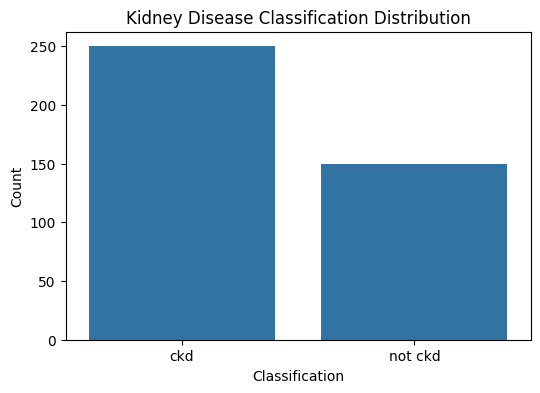

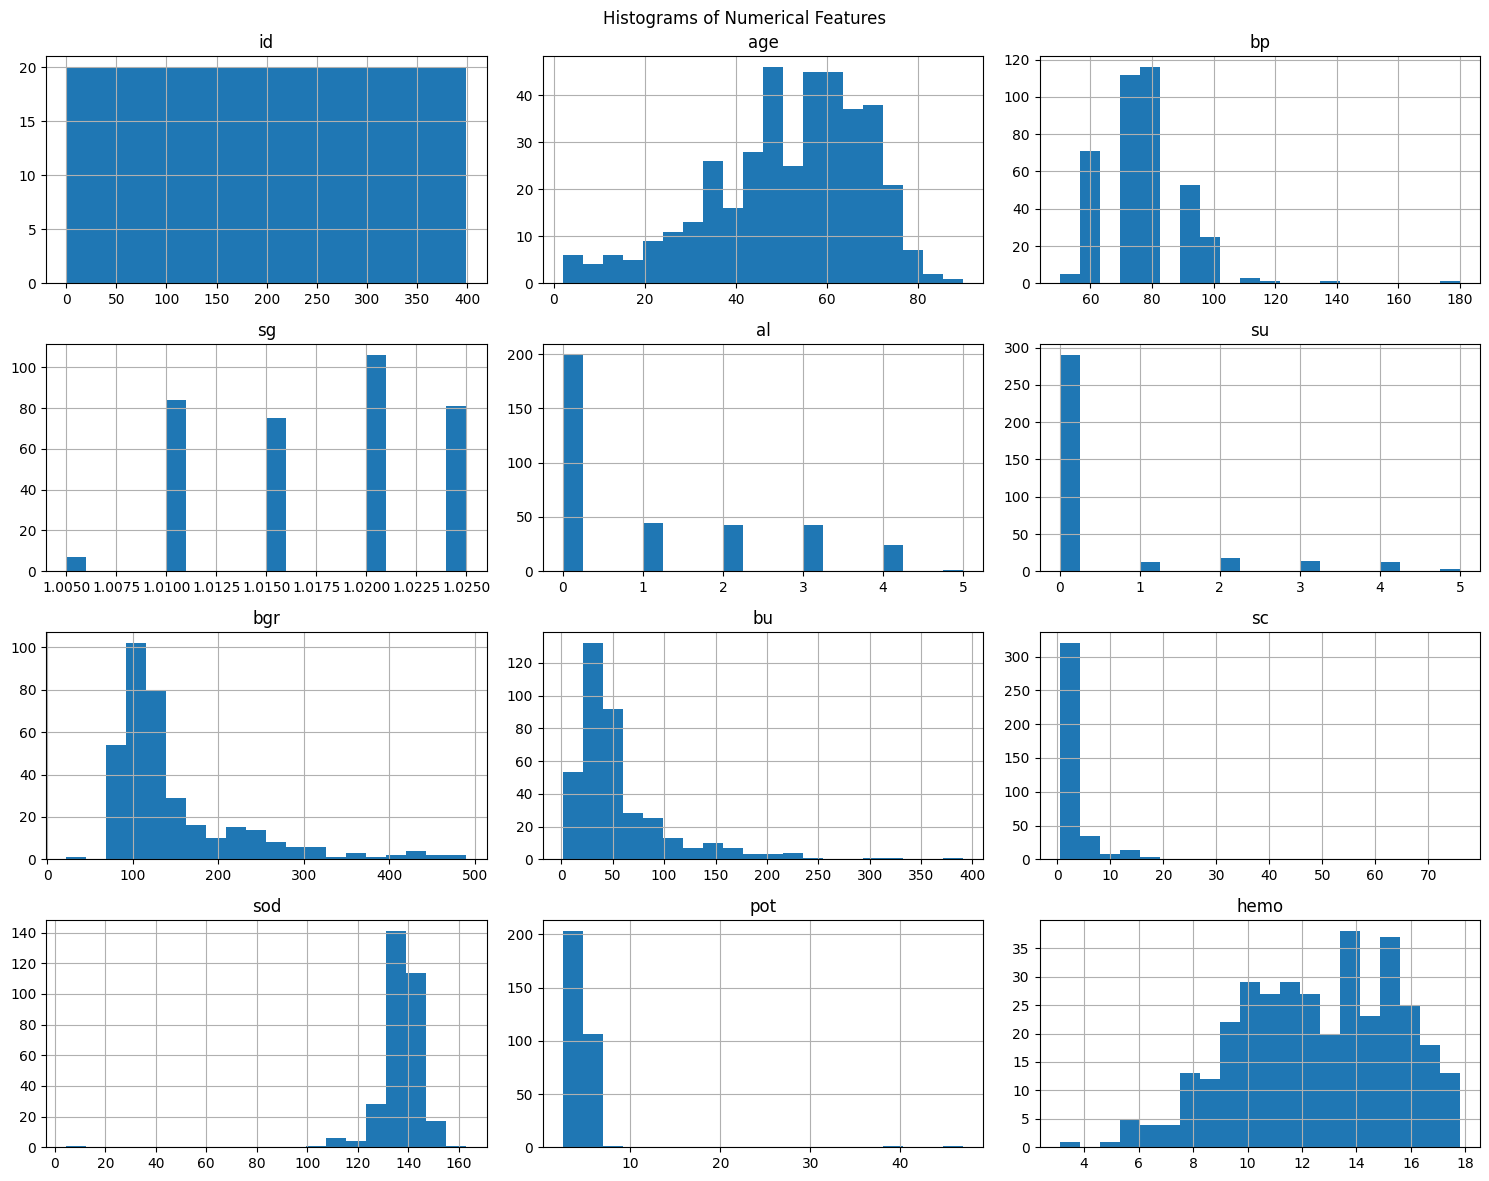

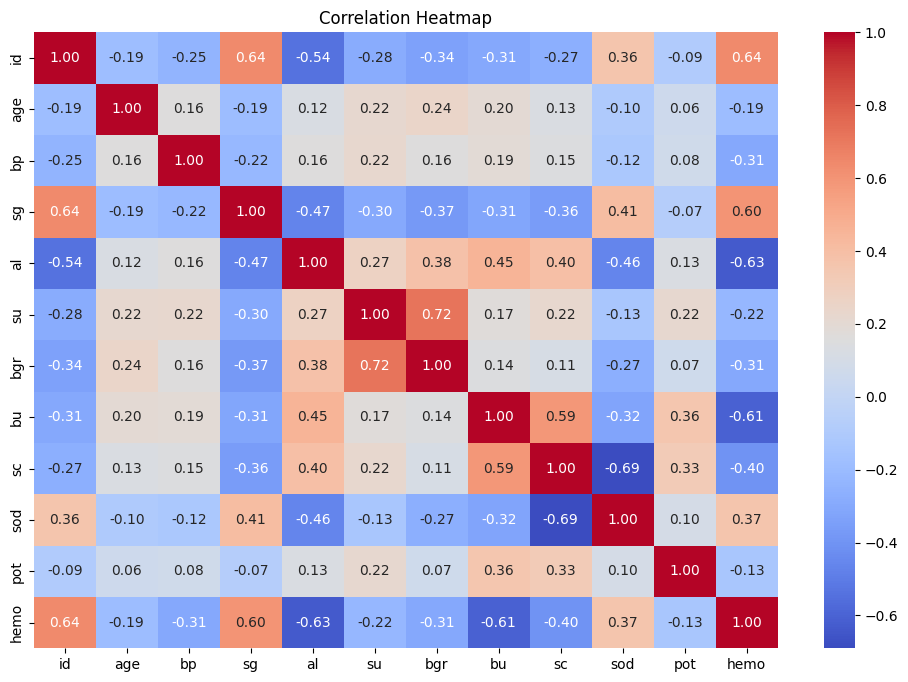


Numerical features:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Categorical features:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Training data: (320, 24)
Testing data: (80, 24)

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


KNN Classification
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                 

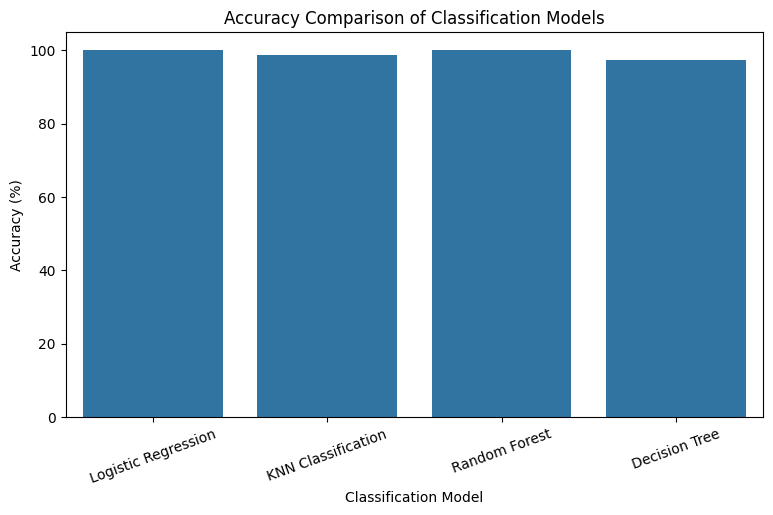

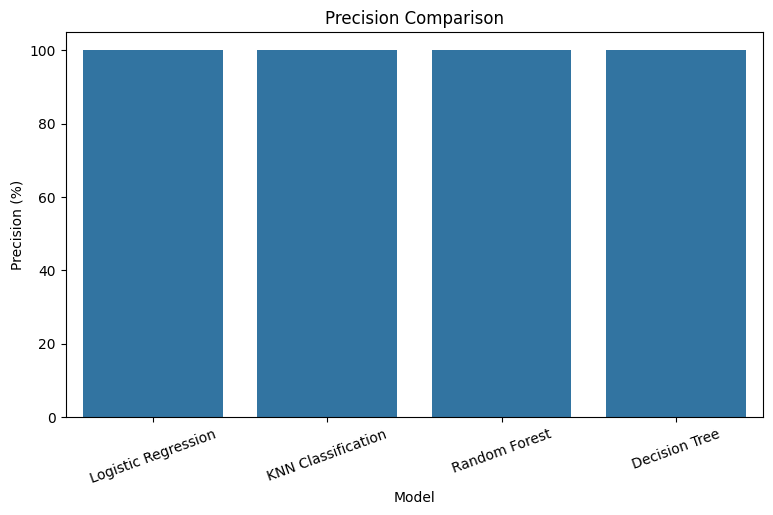

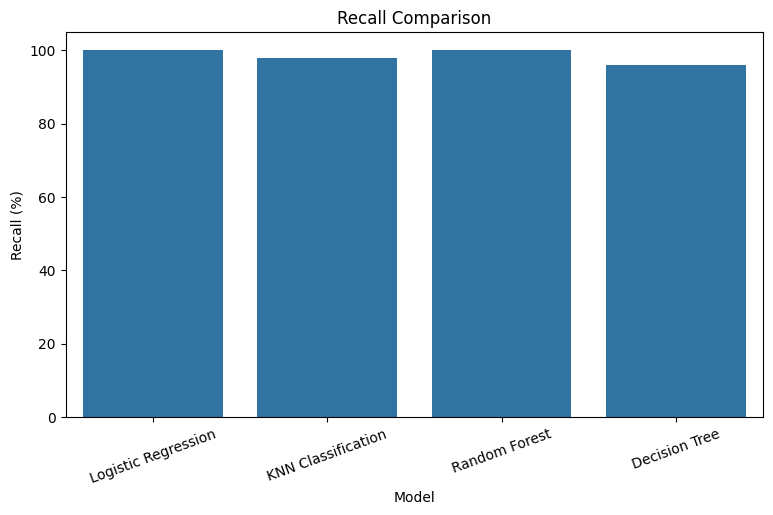

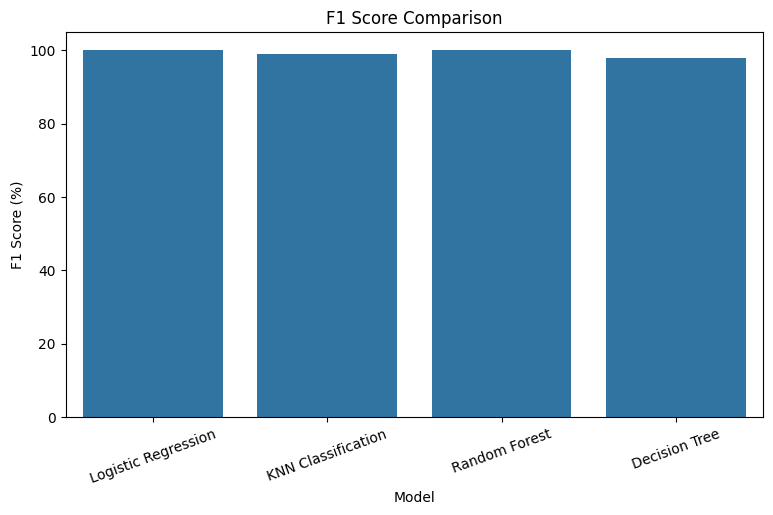

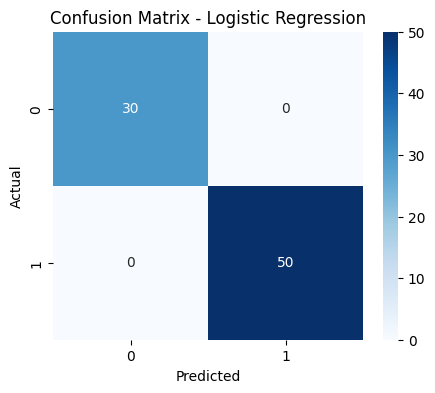

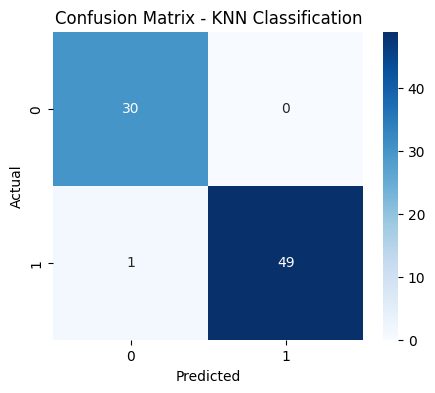

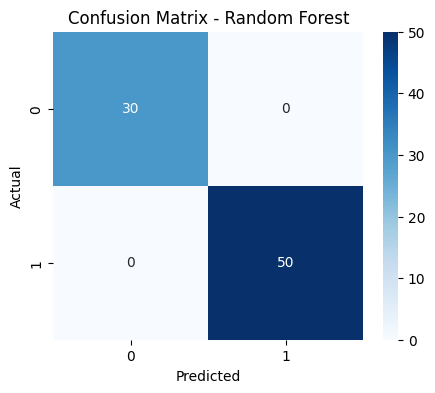

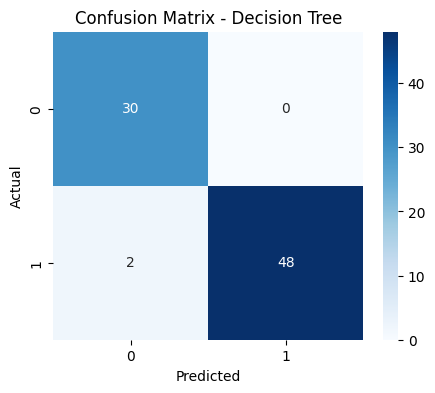


FINAL CONCLUSION
The classification models were evaluated using Accuracy, Precision, Recall and F1 Score.
Highest Accuracy: 100.0 %
Highest Accuracy Model(s): Logistic Regression, Random Forest


In [ ]:
# ============================================================
# KIDNEY DISEASE CLASSIFICATION - COMPLETE PROJECT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. DATA COLLECTION / DATA LOADING
# ============================================================
from google.colab import files
uploaded = files.upload()

# Load the dataset
data = pd.read_csv('kidney_disease.csv')

print("Dataset loaded successfully!")
print("Shape of dataset:", data.shape)


# ============================================================
# 3. BASIC DATA EXPLORATION
# ============================================================

print("\nFirst 5 rows:")
print(data.head())

print("\nColumn names:")
print(data.columns)

print("\nDataset information:")
print(data.info())

print("\nStatistical description:")
print(data.describe())


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")
print(data.isnull().sum())


# ============================================================
# 5. DATA CLEANING
# ============================================================

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Remove extra spaces from categorical values
for column in data.select_dtypes(include='object').columns:
    data[column] = data[column].astype(str).str.strip().str.lower()

# Fix target values
data['classification'] = data['classification'].replace({
    'ckd\t': 'ckd',
    'notckd': 'not ckd'
})

print("\nClassification values:")
print(data['classification'].value_counts())


# ============================================================
# 6. DATA VISUALIZATION - CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(x='classification', data=data)

plt.title("Kidney Disease Classification Distribution")
plt.xlabel("Classification")
plt.ylabel("Count")
plt.show()


# ============================================================
# 7. HISTOGRAMS
# ============================================================

numeric_columns = data.select_dtypes(include=np.number).columns

data[numeric_columns].hist(
    figsize=(15,12),
    bins=20
)

plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


# ============================================================
# 8. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))

correlation = data[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


# ============================================================
# 9. PREPARE INPUT AND OUTPUT
# ============================================================

# Remove ID because it is not useful for prediction
X = data.drop(columns=['classification', 'id'])

# Convert target into numerical values
y = data['classification'].map({
    'ckd': 1,
    'not ckd': 0
})

# Remove rows where target is missing
valid_rows = y.notna()

X = X[valid_rows]
y = y[valid_rows]


# ============================================================
# 10. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
# 12. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),

        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)


# ============================================================
# 13. DEFINE FOUR CLASSIFICATION MODELS
# ============================================================

models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    'KNN Classification':
        KNeighborsClassifier(
            n_neighbors=5
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    'Decision Tree':
        DecisionTreeClassifier(
            random_state=42
        )
}


# ============================================================
# 14. TRAIN AND EVALUATE ALL MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n======================================")
    print(name)
    print("======================================")

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    trained_models[name] = pipeline


# ============================================================
# 15. CREATE RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print("\n======================================")
print("FINAL MODEL COMPARISON")
print("======================================")

print(results_df)


# ============================================================
# 16. CONVERT METRICS INTO PERCENTAGE
# ============================================================

results_percentage = results_df.copy()

results_percentage[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] = results_percentage[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
] * 100

print("\nResults in Percentage:")
print(results_percentage.round(2))


# ============================================================
# 17. FIND HIGHEST ACCURACY
# ============================================================

highest_accuracy = results_df['Accuracy'].max()

best_models = results_df[
    results_df['Accuracy'] == highest_accuracy
]['Model'].tolist()

print("\n======================================")
print("HIGHEST ACCURACY")
print("======================================")

print("Highest Accuracy:",
      highest_accuracy * 100, "%")

print("Model(s) with highest accuracy:")

for model in best_models:
    print("-", model)


# ============================================================
# 18. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_percentage
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Classification Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.ylim(0, 105)

plt.show()


# ============================================================
# 19. PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    x='Model',
    y='Precision',
    data=results_percentage
)

plt.title("Precision Comparison")
plt.ylabel("Precision (%)")

plt.xticks(rotation=20)

plt.ylim(0, 105)

plt.show()


# ============================================================
# 20. RECALL COMPARISON
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    x='Model',
    y='Recall',
    data=results_percentage
)

plt.title("Recall Comparison")
plt.ylabel("Recall (%)")

plt.xticks(rotation=20)

plt.ylim(0, 105)

plt.show()


# ============================================================
# 21. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_percentage
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score (%)")

plt.xticks(rotation=20)

plt.ylim(0, 105)

plt.show()


# ============================================================
# 22. CONFUSION MATRIX FOR EACH MODEL
# ============================================================

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title("Confusion Matrix - " + name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()


# ============================================================
# 23. FINAL CONCLUSION
# ============================================================

print("\n======================================")
print("FINAL CONCLUSION")
print("======================================")

print(
    "The classification models were evaluated using "
    "Accuracy, Precision, Recall and F1 Score."
)

print(
    "Highest Accuracy:",
    highest_accuracy * 100,
    "%"
)

print(
    "Highest Accuracy Model(s):",
    ", ".join(best_models)
)